# **SunoikisisDC Digital Scholarly Editions in Classics, Byzantine, and Medieval Studies: Session 7 - Exercise:  Exploring Pliny the Elder’s Naturalis Historia through Semantic Linking**

This notebook guides you through the necessary steps to analyze the distribution of geographical origin and spoken language of people mentioned in book 2 of the _Naturalis Historia_ by Pliny the Elder.

**NB**: To start, be sure to have uploaded the provided database (**"nh2_sample_sunoikisis.csv"**) in the File section of GoogleColab.

The provided dataframe consists of a simplified version of the text used to perform the analysis shown during the presentation.

## Importing libraries and loading the data


The first necessary step is to import the two libraries we need for the exercise:


*   **pandas**: necessary to manipulate dataframes
*   **matplotlib**: necessary to generate the visualizations




In [ ]:
import pandas as pd

import matplotlib.pyplot as plt


Then we load the dataframe. Here, each row is constituted by a textual token, which has its own unique combination of "wordref_id" + "extra". The other columns contain the values previously extracted from wikidata for the following properties:


1.	Instance of (P31)
2.  Country of citizenship (P27);
2.	Languages spoken, written or signed: (P1412);
3.	Occupation (P106);
4. Sex or gender (P21)







In [ ]:
#loading the dataframe
df = pd.read_csv("nh2_sample_sunoikisis.csv")
df

,wordref_id,extra,sent_id,book,section,capitalized,token,gold_ner,wikidata,TM_Real,...,citizenship_id,citizenship_label,language_id,language_label,occupation_id,occupation_label,sex_or_gender_id,sex_or_gender_label,Wikidata_label,merged_entity_id
0,1766059,NaN,2_0,2.0,1.0,1,Mundum,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
1,1766060,NaN,2_0,2.0,1.0,0,et,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,1766061,NaN,2_0,2.0,1.0,0,hoc,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,1766062,NaN,2_0,2.0,1.0,0,quodcumque,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,1766063,NaN,2_0,2.0,1.0,0,nomine,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20707,1786951,NaN,2_791,2.0,109.0,0,partem,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
20708,1786952,NaN,2_791,2.0,109.0,0,totius,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
20709,1786953,NaN,2_791,2.0,109.0,0,mundi,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
20710,1786954,NaN,2_791,2.0,109.0,0,facit,%,%,%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


## Creating a filter for authors


To analyze the distribution of geographical origins and language in the book, we want to be able to make a distinction between authors and not authors. This is important when working with Pliny's encyclopedia, to be able to filter the results on the basis of the kind of analysis we want to do.

To achieve this, we base the distinction on the **occupation** property. Since each occupation field contains multiple values, we define as authors all the persons which have at least one of the following values in the field:

- writer "Q36180"
- philosopher "Q4964182"
- poet "Q49757"
- astronomer "Q11063"
- mathematician "Q170790"
- astronomer "Q11063"
- biologist "Q864503"
- orator "Q12859263"
- historian "Q201788"
- explorer "Q11900058"
- jurist "Q185351"
- bematist "Q816349"
- physician "Q39631"
- elegist "Q16868675"
- surveyor "Q294126"
- geographer "Q901402"
- architect "Q42973"

Note: we can be guided by the above mentioned "authorial" values of the property because in Pliny's case it is way more frequent that sources are also politicians, whereas the opposite is (almost never) true (figures who are not sources rarely play any authorial role). In the largest amount of cases, authors appear in the text solely as cited sources. In any case, when working on your own project, it's always better to check for exceptions, in order to handle them properly.

In [ ]:
authors_occupation_labels = ["Q36180", "Q4964182", "Q49757", "Q11063", "Q170790", "Q11063", "Q864503", "Q12859263", "Q201788", "Q11900058",
                            "Q185351", "Q816349", "Q39631", "Q16868675", "Q294126", "Q901402", "Q42973" ]

In [ ]:
def is_author(occupation_id, authors_occupation_labels, human_label):
    """
    Check if the occupation id contains at least one authorial occupation
    """
    if human_label == False: #ignoring not humans
        return "not_human"

    elif human_label == True:

        if pd.isna(occupation_id): #if no occupation specified
            return "unspec"

        if any(author_id in str(occupation_id) for author_id in authors_occupation_labels):
            return True
        else:
            return False


df['is_author'] = df.apply( #applying the function
    lambda row: is_author(row['occupation_id'], authors_occupation_labels, row['is_human']),
                         axis = 1)

## Geography analysis

### Dividing the persons according to their geographical origin

The values of the citizenship property do not contain homogeneous information.
In order to analyze the geographical origin of the mentioned individual, it's necessary to organize this information in a different way. In this case, we divide them into 4 groups: for the division into African and Asian continent, we follow a basic criterion, aligned with modern conceptualizations.

Sometimes, the citizenship value could be empty: in that case, we use the language value to integrate the missing information

In [ ]:
rome = ['Q1747689', 'Q9160295']
greece = ['Q1568260','Q169460', 'Q13580795', 'Q11936633', 'Q833665', 'Q844930', 'Q83958', 'Q1233764', 'Q5843680',
         'Q244796', 'Q11266977']
asia = ['Q93180', 'Q389688', 'Q22647',  'Q2022162',   'Q1986139', 'Q1062946', 'Q620765',  'Q7380487']
africa = ['Q2320005', 'Q163490', 'Q2429397', 'Q6343', 'Q309272', 'Q102679', 'Q11768', 'Q16000109' ]

In [ ]:
def categorize_by_region(value_geo, value_lang, human_label):
  """
  Categorizing the persons according to their geographical origin
  """
  if human_label == False: #ignoring not humans
        return "not_human"

  else:

    if pd.notna(value_geo): #checking if there's a value
        value_str = str(value_geo) #making the value a string

        if any(country in value_str for country in rome): #looping through defined values
            return "Roma"
        elif any(country in value_str for country in greece):
            return "Graecia"
        elif any(country in value_str for country in asia):
            return "Asia"
        elif any(country in value_str for country in africa):
            return "Africa"
        else:
            return "Other"

    #fallback on language, if citizenship not available

    elif pd.notna(value_lang):
        if value_lang in ['Q397', 'Q36653']: #latin and oscan
            return "Roma"
        elif value_lang == "Q35497": #ancient greek
                return "Graecia"
        elif value_lang in ["Q11059", "Q35225", "Q8785"]: #sanskrit, old persian and armenian
            return "Asia"
        else:
            return "Other"

df['citizenship_group'] = df.apply(
    lambda row: categorize_by_region(row['citizenship_id'], row['language_id'], row['is_human']),
    axis=1
)

print(df['citizenship_group'].value_counts())


citizenship_group
Roma         157
Graecia       71
not_human     59
Asia           7
Africa         4
Name: count, dtype: int64


### Visualizing distribution every 1000 tokens

To count the occurrences of each person, it's important to consider those represented by multiple names (tagged as B-PERS I-PERS in the "gold_ner" field) as one single mention. If not, we would have a disproportionate representation of Roman citizens (often represented by the _tria nomina_) at the expense of individuals with a single name.

The provided dataframe already features a column called **"merged_entity_id"**, which contains a unique number for each multi-token entity. By **dropping the duplicates** in that columns, we will be left with one token for each mentioned individual.

Since this process will drop also all the other textual tokens, it is crucial that **we divide the text in groups of 1000 tokens each as first step**. The resulting groups will still reflect the original distribion.


In [ ]:
#divide the text in groups of 1000 tokens
#reindexing to have a clean index (drop=True drops the previous index)
df['group'] = df.reset_index(drop=True).index // 1000

#BIO merging: keep only the first token
merged_ents_df = df.drop_duplicates(subset='merged_entity_id', keep='first')


#counting results
citiz_df_results = (
    merged_ents_df
    .groupby('group')['citizenship_group'] #group based on citizenship and group of 1000 tokens
    .value_counts() #count values
    .unstack(fill_value=0) #pivots the citizenship values from rows into columns
    .reindex(range(0, df['group'].max() + 1), fill_value=0)  # fill empty groups while reindexing, to be sure that also empty groups are represented
)

#ensure that all the categories are present and reindex
categories = ['Roma', 'Graecia', 'Asia', 'Africa', 'Germania']
citiz_df_results = citiz_df_results.reindex(columns=categories, fill_value=0)



For plotting our results in a bar graph, we use the **matplotlib** Python library.

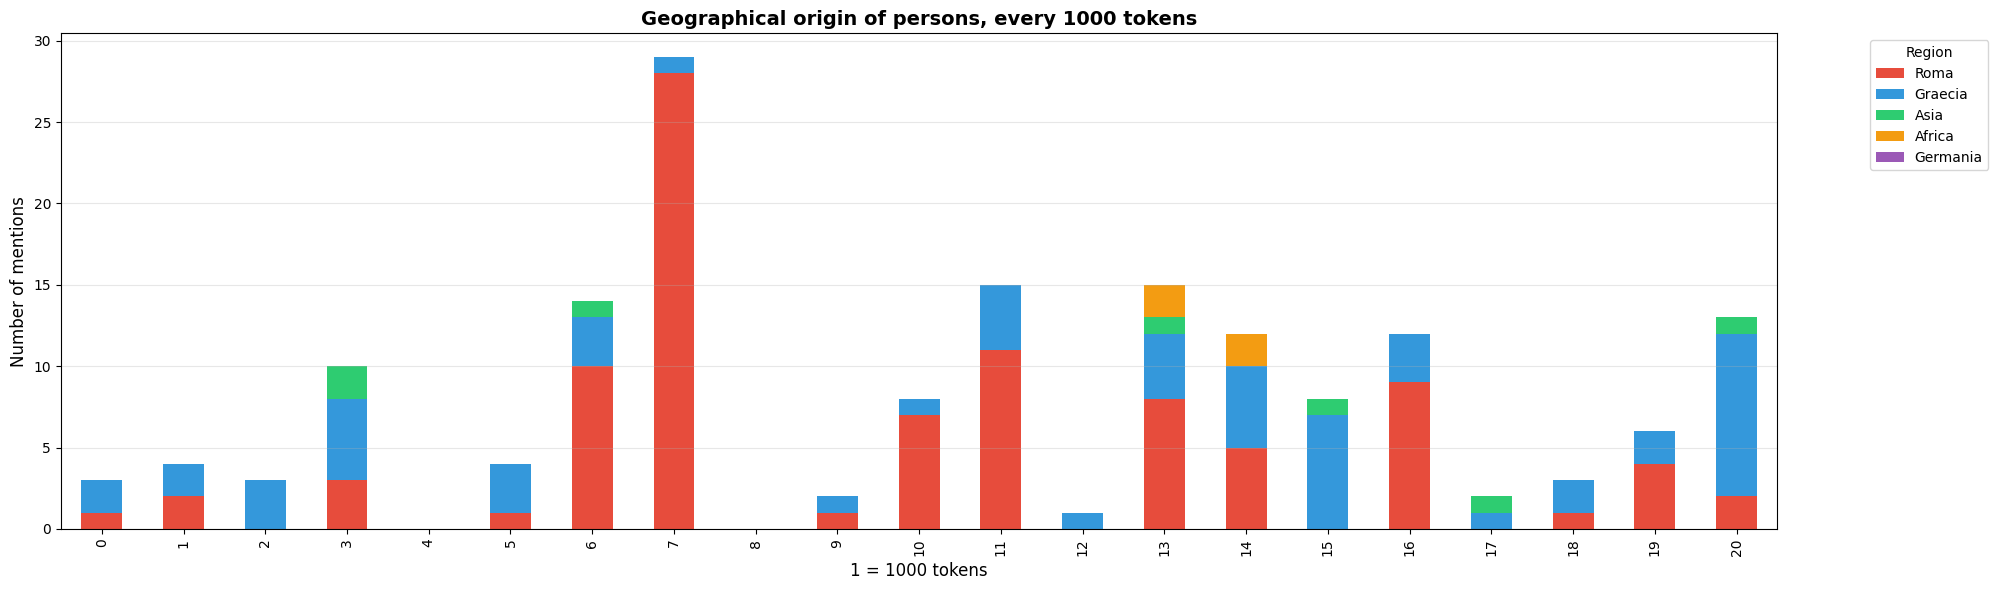

In [ ]:
#plotting
fig, ax = plt.subplots(figsize=(20, 6)) #defining the blank canvas (fig), and the coordinate system (ax) + giving size to fig.
citiz_df_results.plot(
    kind='bar', stacked=True, ax=ax, #defining the type of graph
    color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6'] #defining the colors
)
ax.set_xlabel('1 = 1000 tokens', fontsize=12) #defining the x label
ax.set_ylabel('Number of mentions', fontsize=12) #defining the y label
ax.set_title('Geographical origin of persons, every 1000 tokens', fontsize=14, fontweight='bold') #defining the title
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left') #defining the legend and its position
ax.grid(axis='y', alpha=0.3) #adding horizontal lines to better read the results
plt.tight_layout() #adjusting spacing
# plt.show()
plt.savefig("geographical_distribution.png")

## Language analysis: focusing on the authors

### Creating language groups

The procedure to analyze the language spoken by the individuals is analogous: we organize the heterogenous information into three groups, i.e. Latin, Greek and Other.

Modelling the language separately from the citizenship allows us to **distinguish between the cultural and geographical element**: many people living on the African and Asian continent spoke (and most importantly wrote!) in Greek, sharing the Hellenistic culture.

In [ ]:
latin_lang = ["Q397"]
greek_lang = ["Q35497", "Q406373", "Q107358"]
other_lang = ["Q535958", "Q36653", "Q36095", "Q35225", "Q50868", "Q946997", "Q35470", "Q11059", "Q8785"]

def categorize_by_language(value_lang, human_label):
  """
  Categorizing by language
  """
  if human_label == False: #ignoring not humans
        return "not_human"

  else:

    if pd.notna(value_lang): #if language value is present
        value_str = str(value_lang) #make it a string

        if  "Q397" in value_str:
            return "Latin"
        elif any(lang in value_str for lang in greek_lang):
            return "Greek"
        else:
            return "Other"



df['language_group'] = df.apply(
    lambda row: categorize_by_language(row['language_id'], row['is_human']),
    axis=1
)

print(df['language_group'].value_counts())

language_group
Latin        130
Greek         79
not_human     59
Other          1
Name: count, dtype: int64


### Visualizing the distribution over 1000 tokens

We follow again the same procedure as before, but in this case we keep only the authors, thanks to the filter we created at the beginning of the exercise.


In [ ]:
#divide the text in groups of 1000 tokens
df['group'] = df.groupby('book').cumcount() // 1000

#BIO merging: keep only the first token
merged_ents_df = df.drop_duplicates(subset='merged_entity_id', keep='first')

#keeping only the authors
merged_ents_df_authors = merged_ents_df[merged_ents_df['is_author'] == True]

#counting results
lang_df_results = (
    merged_ents_df_authors
    .groupby('group')['language_group'] #group based on language and group of 1000 tokens
    .value_counts() #count values
    .unstack(fill_value=0) #pivots the citizenship values from rows into columns
    .reindex(range(0, df['group'].max() + 1), fill_value=0)  # fill empty groups while reindexing
)

#ensure that all the categories are present and reindex
categories = ['Latin', 'Greek', 'Other']
lang_df_results = lang_df_results.reindex(columns=categories, fill_value=0)

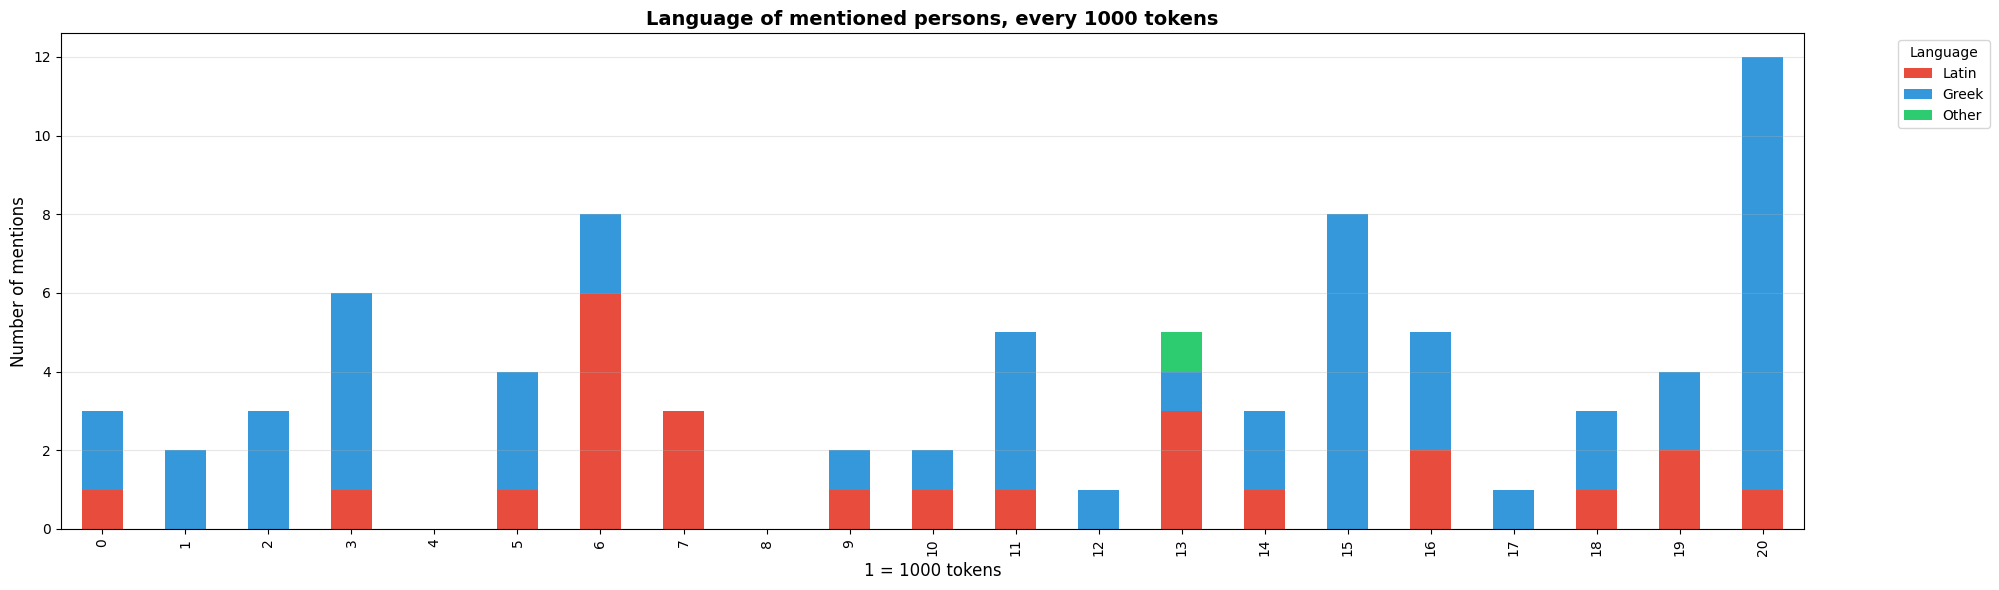

In [ ]:
#plotting
#see the guiding comments of the previous graph
fig, ax = plt.subplots(figsize=(20, 6))
lang_df_results.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']
)
ax.set_xlabel('1 = 1000 tokens', fontsize=12)
ax.set_ylabel('Number of mentions', fontsize=12)
ax.set_title('Language of mentioned persons, every 1000 tokens', fontsize=14, fontweight='bold')
ax.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig("language_distribution.png")

### Unique individuals

Now let's focus on unique individuals. Since each linked person is identified by a **unique wikidata Qid**, we can easily drop the duplicates from this field and be left with only the unique individuals

In [ ]:
#BIO merging: keep only the first token
merged_ents_df = df.drop_duplicates(subset='merged_entity_id', keep='first')

#keeping only the authors
merged_ents_df_authors = merged_ents_df[merged_ents_df['is_author'] == True]

#keeping unique individuals
unique_merged_author_df = merged_ents_df_authors.drop_duplicates(subset='wikidata_qid')

# Count unique authors per language group
lang_df_results_unique = unique_merged_author_df['language_group'].value_counts()

# Ensure all categories are present
categories = ['Latin', 'Greek', 'Other']
lang_df_results_unique = lang_df_results_unique.reindex(categories, fill_value=0)

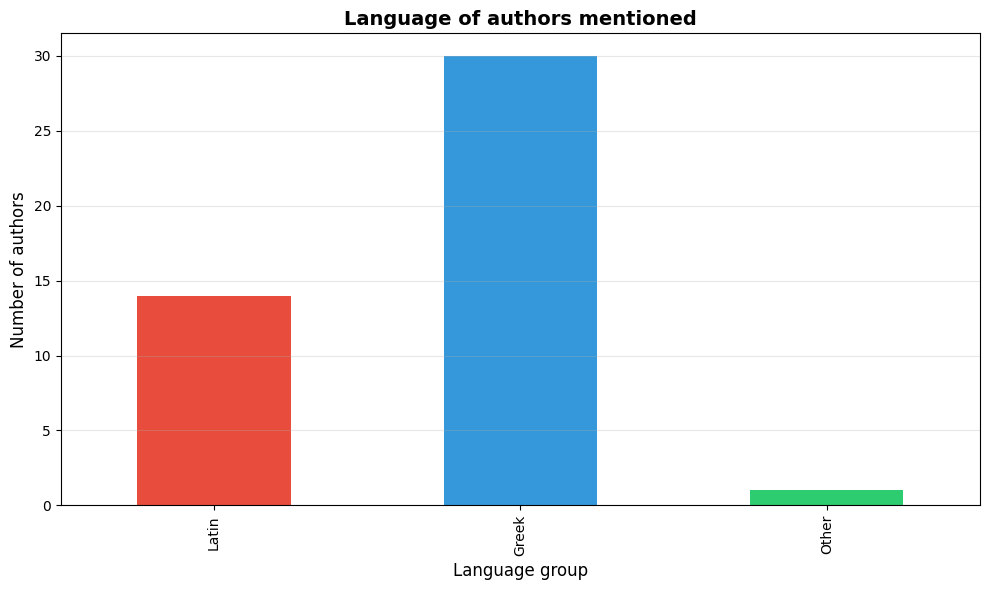

In [ ]:
#plotting
fig, ax = plt.subplots(figsize=(10, 6))

lang_df_results_unique.plot(
    kind='bar', ax=ax,
    color=['#e74c3c', '#3498db', '#2ecc71']
)

ax.set_xlabel('Language group', fontsize=12)
ax.set_ylabel('Number of authors', fontsize=12)
ax.set_title('Language of authors mentioned', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig("language_distribution_unique.png")

To compare the total number of mentions with the unique individuals, thus focusing on how many times each unique author is mentioned, we simply calculate the ratio between the mentions and the unique individuals

                mentions  unique_authors  mentions_per_author
language_group                                               
Latin                 25              14             1.785714
Greek                 54              30             1.800000
Other                  1               1             1.000000


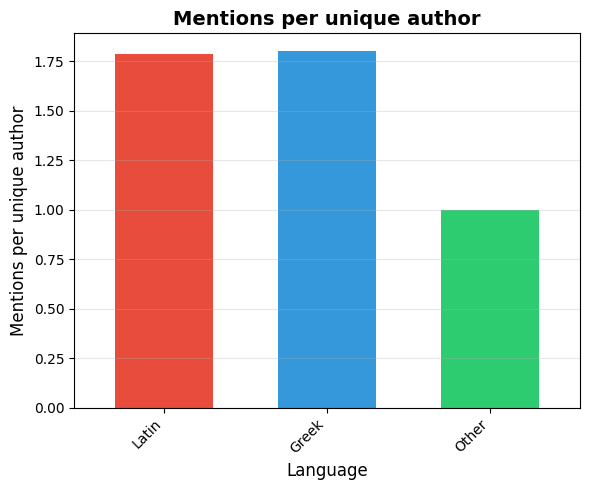

In [ ]:

#Total mentions per language group
mentions = merged_ents_df_authors.groupby("language_group").size()

#Unique authors per language group
unique_authors = merged_ents_df_authors.groupby("language_group")["wikidata_qid"].nunique()

#df with mention/author ratio
ratio_df = pd.DataFrame({
    "mentions": mentions,
    "unique_authors": unique_authors
}).reindex(["Latin", "Greek", "Other"])  # ensure consistent order

ratio_df["mentions_per_author"] = ratio_df["mentions"] / ratio_df["unique_authors"]
print(ratio_df)

#plotting
fig, ax = plt.subplots(figsize=(6, 5))

ratio_df["mentions_per_author"].plot(
    kind="bar",
    color=['#e74c3c', '#3498db', '#2ecc71'],
    ax=ax,
    width=0.6
)

ax.set_xlabel("Language", fontsize=12)
ax.set_ylabel("Mentions per unique author", fontsize=12)
ax.set_title("Mentions per unique author", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') #rotating the labels on the x axis
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ratio_mention_unique_allbooks.png")
plt.show()

Now all your images are saved in the files folder!